# Exercise set 4

**Exercise 1**

Using all the Python modules you need compute the following distances:

a. Compute the $L_p$ distance between $(1, 2)$ and $(3, 4)$ for $p = 1, 2, âˆž$.

b. Given two objects represented by the tuples $(22, 1, 42, 10)$ and $(20, 0, 36, 8)$:

1. Compute the Euclidean distance between the two objects.
2. Compute the Manhattan distance between the two objects.
3. Compute the Minkowski distance between the two objects, using $h = 3$.
4. Compute the supremum distance ($L_âˆž$) between the two objects.


In [1]:
from scipy.spatial.distance import minkowski
from scipy.spatial.distance import chebyshev
import math

#definiamo nostri punti

p1 = [1,2]
p2 = [3,4]

# a.1: p = 1 (Manhattan)

dist_p1 = minkowski(p1,p1,p=1)

#Oppure specificatamente: distance.cityblock(p1,p2)
print(f"L1 (Manhattan): {dist_p1}")

# a.2: p = 2 (Euclidea)

dist_p2 = minkowski(p1,p2, p=2)
#oppure specificatamente : distance.euclidean(p1,p2)
print(f"L2 (Euclidea): {dist_p2}")

# a.3: p = 3 (Chebyshev)

dist_p_inf = chebyshev(p1,p2)
print(f"L_inf (Chebyshev): {dist_p_inf}")

#definizione delle tuple

obj1 = [22, 1, 42, 10]
obj2 = [20, 0, 36, 8]

# b.1 Euclidea
b_euclid = minkowski(obj1, obj2, p=2)
print(f"1. Euclidea: {b_euclid}")

# b.2 Manhattan
b_manhattan = minkowski(obj1, obj2, p=1)
print(f"2. Manhattan: {b_manhattan}")

# b.3 Minkowski con h=3 (p=3)
b_mink_3 = minkowski(obj1, obj2, p=3)
print(f"3. Minkowski (p=3): {b_mink_3}")

# b.4 Supremum (Chebyshev)
b_cheby = chebyshev(obj1, obj2)
print(f"4. Supremum: {b_cheby}")


L1 (Manhattan): 0.0
L2 (Euclidea): 2.8284271247461903
L_inf (Chebyshev): 2
1. Euclidea: 6.708203932499369
2. Manhattan: 11.0
3. Minkowski (p=3): 6.153449493663682
4. Supremum: 6


**Exercise 2**

Download the Ionosphere data set from the UCI Machine Learning Repository, remove the class feature and compute the $L_p$ distance between all pairs of data points, for $p=1,2,âˆž$.

Compute the contrast measure on the data set for the different norms.

Repeat the exercise after sampling the first $r$ dimensions, where $r$ varies from 1 to the full dimensionality of the data.

(351, 34)
Calcolo in corso...


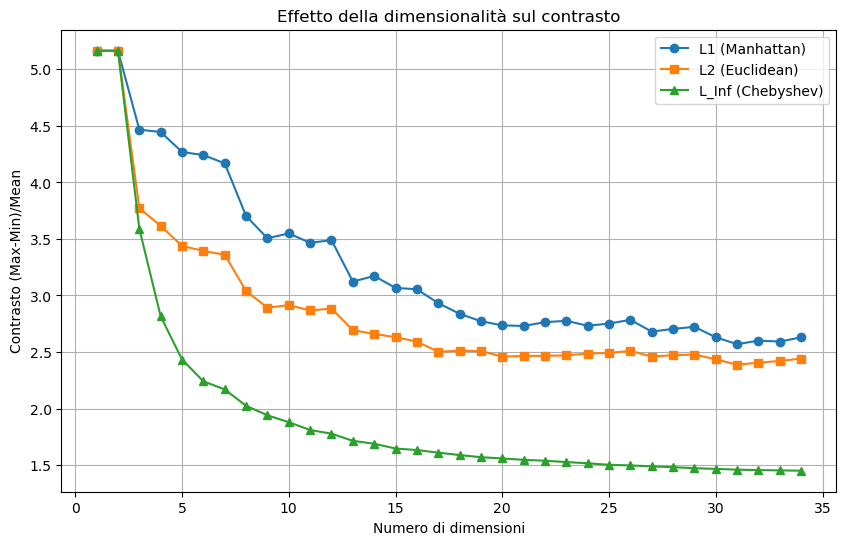

In [5]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

labels=list(range(1, 35)) + ['class']
df = pd.read_csv('http://www.lacascia.it/bd2/_ionosphere/ionosphere.data', names=labels)

# 2. Rimozione della classe (l'ultima colonna, la 34esima indice 34)
# Selezioniamo tutte le righe e tutte le colonne tranne l'ultima
data = df.iloc[:, :-1].to_numpy(copy=True)
print(data.shape)

def compute_contrast(data,metric):
    #pdist calcola le distanze a coppie in modo efficiente
    #Restituisce un array condensato (senza zeri diagonali)
    dists = pdist(data, metric=metric)

    d_min = np.min(dists)
    d_max = np.max(dists)
    d_mean = np.mean(dists)

    #formula del contrasto
    if d_mean == 0: return 0
    return (d_max - d_min) / d_mean

#Liste per salvare i risultati
dims = range(1, data.shape[1] + 1) #da 1 a 34
results_l1 = [] #Manhattan
results_l2 = [] #Euclidea
results_linf = [] #Chebyshev

#3 Iterazione sulle dimensioni(r)
print("Calcolo in corso...")
for r in dims:
    data_subset = data[:, :r]
    #Calcoliamo il contrasto per le tre metriche

    #p=1 (Manhattan) -> 'cityblock' in scipy
    results_l1.append(compute_contrast(data_subset,'cityblock'))

    #p=2 (Euclidean) -> 'euclidean' in scipy
    results_l2.append(compute_contrast(data_subset, 'euclidean'))

    #p=inf (Chebyshev) -> 'chebyshev' in scipy
    results_linf.append(compute_contrast(data_subset, 'chebyshev'))

#4 Plot dei risultati

plt.figure(figsize=(10,6))
plt.plot(dims, results_l1, label='L1 (Manhattan)', marker='o')
plt.plot(dims, results_l2, label='L2 (Euclidean)', marker='s')
plt.plot(dims, results_linf, label='L_Inf (Chebyshev)', marker='^')

plt.xlabel('Numero di dimensioni')
plt.ylabel('Contrasto (Max-Min)/Mean')
plt.title('Effetto della dimensionalità sul contrasto')
plt.legend()
plt.grid(True)
plt.show()
